In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries imported and pandas display options set successfully.")

Libraries imported and pandas display options set successfully.


In [2]:
X = pd.read_csv('../../data/apartment/satilir_properties_apartment_processed.csv')
y = pd.read_csv('../../data/apartment/satilir_properties_apartment_target.csv')

df_original = pd.concat([X, y], axis=1)  

print(f"X shape: {X.shape}, y shape: {y.shape}, df_original shape: {df_original.shape}")

X shape: (4273, 43), y shape: (4273, 1), df_original shape: (4273, 44)


In [3]:
X['num__floor'].unique()

array([ 5.,  9., 12.,  2.,  1., 13.,  4.,  8., 14., 10., 18.,  6.,  3.,
        7., 16., 11., 17., 15.])

In [4]:
processed_df = X.copy()
eps = 1e-6
new_cols = []

# Density/layout features
if {'num__area_m2', 'num__rooms'}.issubset(processed_df.columns):
    area = pd.to_numeric(processed_df['num__area_m2'], errors='coerce')
    rooms = pd.to_numeric(processed_df['num__rooms'], errors='coerce')

    processed_df['num__area_per_room'] = area / (rooms + eps)

    new_cols += ['num__area_per_room']

# Apartment-specific floor feature
if 'num__floor' in processed_df.columns:
    floor = pd.to_numeric(processed_df['num__floor'], errors='coerce')
    floor_threshold = floor.dropna().quantile(0.75) if floor.notna().any() else np.nan

    if pd.notna(floor_threshold):
        processed_df['num__high_floor_flag'] = (floor >= floor_threshold).astype(float)
        print(f'High-floor threshold (75th percentile): {floor_threshold:.2f}')
    else:
        processed_df['num__high_floor_flag'] = 0.0
        print('High-floor threshold unavailable, defaulted num__high_floor_flag to 0.')

    new_cols += ['num__high_floor_flag']

# Interaction between floor level and lift availability
if {'num__high_floor_flag', 'yes_no_binary__lift'}.issubset(processed_df.columns):
    lift = pd.to_numeric(processed_df['yes_no_binary__lift'], errors='coerce').fillna(0).clip(0, 1)
    processed_df['num__high_floor_with_lift'] = processed_df['num__high_floor_flag'] * lift
    new_cols += ['num__high_floor_with_lift']

feature_cols = [c for c in processed_df.columns if c.startswith('yes_no_binary__')]
if feature_cols:
    feature_block = processed_df[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
    processed_df['num__feature_score'] = feature_block.mean(axis=1)
    new_cols += ['num__feature_score']

if new_cols:
    processed_df[new_cols] = processed_df[new_cols].replace([np.inf, -np.inf], np.nan)
    processed_df[new_cols] = processed_df[new_cols].fillna(processed_df[new_cols].median(numeric_only=True))

print(f"Added {len(new_cols)} non-log engineered features.")
print('processed_df shape after feature creation:', processed_df.shape)
print('Sample non-log features:', new_cols[:12])
processed_df.head()

High-floor threshold (75th percentile): 9.00
Added 4 non-log engineered features.
processed_df shape after feature creation: (4273, 47)
Sample non-log features: ['num__area_per_room', 'num__high_floor_flag', 'num__high_floor_with_lift', 'num__feature_score']


,yes_no_binary__has_document,yes_no_binary__avtodayanacaq,yes_no_binary__balkon,yes_no_binary__duzelme,yes_no_binary__esyali,yes_no_binary__hovuz,yes_no_binary__internet,yes_no_binary__isiq,yes_no_binary__kabel_tv,yes_no_binary__kombi,yes_no_binary__kondisioner,yes_no_binary__lift,yes_no_binary__merkezi_qizdirici_sistem,yes_no_binary__metbex_mebeli,yes_no_binary__pvc_pencere,yes_no_binary__qaz,yes_no_binary__su,yes_no_binary__telefon,yes_no_binary__temirli,cat_ohe__rooms_group_1-2,cat_ohe__rooms_group_3-4,cat_ohe__rooms_group_5-6,cat_ohe__rooms_group_infrequent_sklearn,cat_ohe__address_part_1_Bakı,cat_ohe__address_part_1_Sumqayıt,cat_ohe__address_part_1_Xırdalan,cat_ohe__address_part_1_infrequent_sklearn,cat_ohe__address_part_2_ Abşeron,cat_ohe__address_part_2_ Binəqədi,cat_ohe__address_part_2_ Nizami,cat_ohe__address_part_2_ Nərimanov,cat_ohe__address_part_2_ Nəsimi,cat_ohe__address_part_2_ Sabunçu,cat_ohe__address_part_2_ Suraxanı,cat_ohe__address_part_2_ Səbail,cat_ohe__address_part_2_ Xətai,cat_ohe__address_part_2_ Yasamal,cat_ohe__address_part_2_None,cat_ohe__address_part_2_infrequent_sklearn,num__rooms,num__area_m2,num__floor,num__rooms_group_code,num__area_per_room,num__high_floor_flag,num__high_floor_with_lift,num__feature_score
0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,65.0,5.0,2.0,21.666659,0.0,0.0,0.684211
1,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,197.0,9.0,2.0,49.249988,1.0,1.0,0.894737
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,54.0,12.0,1.0,26.999987,1.0,0.0,0.000000
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,100.0,2.0,2.0,24.999994,0.0,0.0,0.157895
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,44.0,1.0,1.0,43.999956,0.0,0.0,0.052632


Original feature skewness (before vs after log):
     feature  raw_skew  log_skew  abs_improvement
0  Area (m2)    1.5641    0.3468           1.2173
1      Floor    0.7959   -0.1719           0.6240


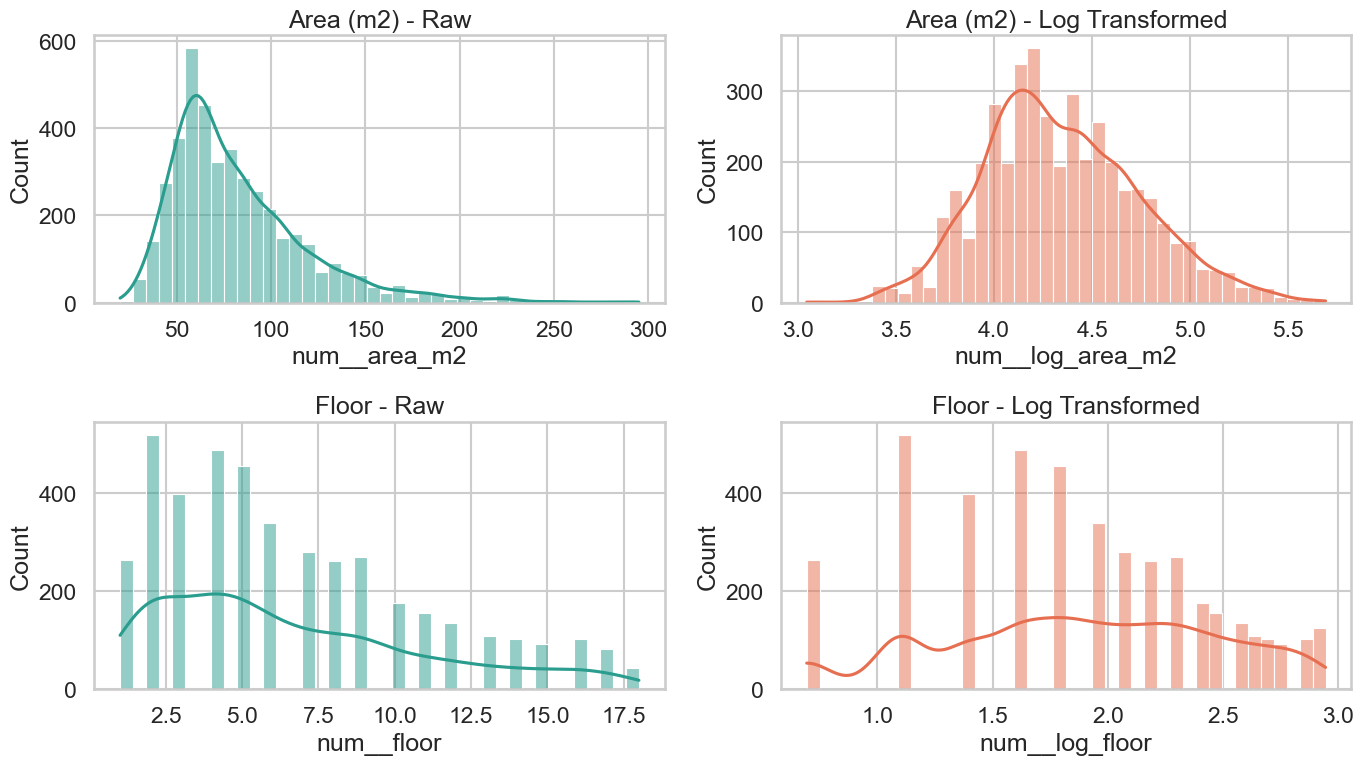

Added 3 log features.
processed_df shape after log transforms: (4273, 50)
Log features: ['num__log_area_m2', 'num__log_floor', 'num__log_area_per_room']


In [5]:
log_cols = []

sns.set_theme(style='whitegrid', context='talk')

# Apply log transforms after base engineered features are created
log_pairs = [
    ('num__area_m2', 'num__log_area_m2'),
    ('num__floor', 'num__log_floor'),
    ('num__area_per_room', 'num__log_area_per_room'),
]

for src_col, dst_col in log_pairs:
    if src_col in processed_df.columns:
        vals = pd.to_numeric(processed_df[src_col], errors='coerce').clip(lower=0)
        processed_df[dst_col] = np.log1p(vals)
        log_cols.append(dst_col)

if log_cols:
    processed_df[log_cols] = processed_df[log_cols].replace([np.inf, -np.inf], np.nan)
    processed_df[log_cols] = processed_df[log_cols].fillna(processed_df[log_cols].median(numeric_only=True))
    if 'new_cols' in globals():
        new_cols += [c for c in log_cols if c not in new_cols]

# Visual skewness check for original numeric features
original_pairs = [
    ('num__area_m2', 'num__log_area_m2', 'Area (m2)'),
    ('num__floor', 'num__log_floor', 'Floor'),
]

available_original_pairs = [p for p in original_pairs if p[0] in processed_df.columns and p[1] in processed_df.columns]

if available_original_pairs:
    skew_rows = []
    for raw_col, log_col, label in available_original_pairs:
        raw_vals = pd.to_numeric(processed_df[raw_col], errors='coerce')
        log_vals = pd.to_numeric(processed_df[log_col], errors='coerce')
        skew_rows.append({
            'feature': label,
            'raw_skew': raw_vals.skew(),
            'log_skew': log_vals.skew(),
            'abs_improvement': abs(raw_vals.skew()) - abs(log_vals.skew()),
        })

    skew_original_df = pd.DataFrame(skew_rows).round(4)
    print('Original feature skewness (before vs after log):')
    print(skew_original_df)

    fig, axes = plt.subplots(len(available_original_pairs), 2, figsize=(14, 4 * len(available_original_pairs)))
    if len(available_original_pairs) == 1:
        axes = np.array([axes])

    for i, (raw_col, log_col, label) in enumerate(available_original_pairs):
        raw_vals = pd.to_numeric(processed_df[raw_col], errors='coerce').dropna()
        log_vals = pd.to_numeric(processed_df[log_col], errors='coerce').dropna()

        sns.histplot(raw_vals, bins=40, kde=True, color='#2a9d8f', ax=axes[i, 0])
        axes[i, 0].set_title(f'{label} - Raw')
        axes[i, 0].set_xlabel(raw_col)

        sns.histplot(log_vals, bins=40, kde=True, color='#e76f51', ax=axes[i, 1])
        axes[i, 1].set_title(f'{label} - Log Transformed')
        axes[i, 1].set_xlabel(log_col)

    plt.tight_layout()
    plt.show()
else:
    print('No original raw/log feature pairs available for visualization.')

print(f"Added {len(log_cols)} log features.")
print('processed_df shape after log transforms:', processed_df.shape)
print('Log features:', log_cols)

Engineered feature skewness (before vs after log):
         feature  raw_skew  log_skew  abs_improvement
0  Area per Room    1.0516    0.2826           0.7689


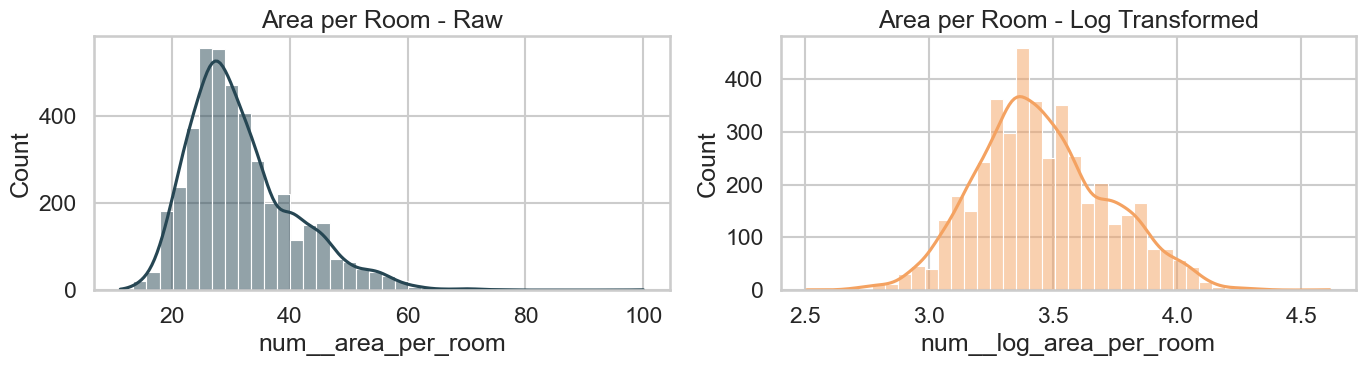

Engineered features intentionally kept on original scale:
['num__feature_score', 'num__high_floor_flag', 'num__high_floor_with_lift']


In [6]:
# Visual skewness check for engineered features
engineered_pairs = [
    ('num__area_per_room', 'num__log_area_per_room', 'Area per Room'),
]

available_engineered_pairs = [p for p in engineered_pairs if p[0] in processed_df.columns and p[1] in processed_df.columns]

if available_engineered_pairs:
    skew_rows = []
    for raw_col, log_col, label in available_engineered_pairs:
        raw_vals = pd.to_numeric(processed_df[raw_col], errors='coerce')
        log_vals = pd.to_numeric(processed_df[log_col], errors='coerce')
        skew_rows.append({
            'feature': label,
            'raw_skew': raw_vals.skew(),
            'log_skew': log_vals.skew(),
            'abs_improvement': abs(raw_vals.skew()) - abs(log_vals.skew()),
        })

    skew_engineered_df = pd.DataFrame(skew_rows).round(4)
    print('Engineered feature skewness (before vs after log):')
    print(skew_engineered_df)

    fig, axes = plt.subplots(len(available_engineered_pairs), 2, figsize=(14, 4 * len(available_engineered_pairs)))
    if len(available_engineered_pairs) == 1:
        axes = np.array([axes])

    for i, (raw_col, log_col, label) in enumerate(available_engineered_pairs):
        raw_vals = pd.to_numeric(processed_df[raw_col], errors='coerce').dropna()
        log_vals = pd.to_numeric(processed_df[log_col], errors='coerce').dropna()

        sns.histplot(raw_vals, bins=40, kde=True, color='#264653', ax=axes[i, 0])
        axes[i, 0].set_title(f'{label} - Raw')
        axes[i, 0].set_xlabel(raw_col)

        sns.histplot(log_vals, bins=40, kde=True, color='#f4a261', ax=axes[i, 1])
        axes[i, 1].set_title(f'{label} - Log Transformed')
        axes[i, 1].set_xlabel(log_col)

    plt.tight_layout()
    plt.show()
else:
    print('No engineered raw/log feature pairs available for visualization.')

not_logged_features = [
    c for c in ['num__feature_score', 'num__high_floor_flag', 'num__high_floor_with_lift']
    if c in processed_df.columns
]
if not_logged_features:
    print('Engineered features intentionally kept on original scale:')
    print(not_logged_features)

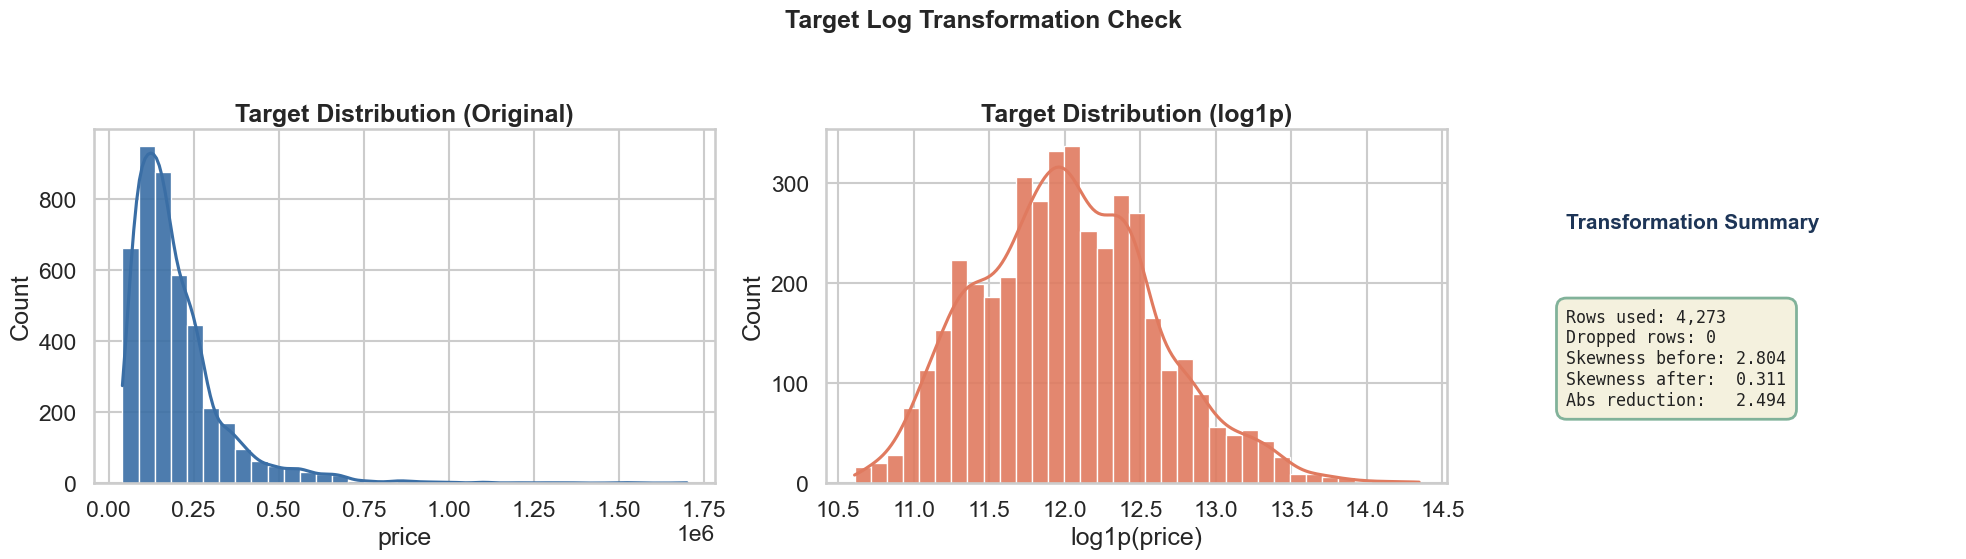

Created target log feature: price_log1p


,price,price_log1p
0,200000,12.206078
1,800000,13.592368
2,210000,12.254868
3,149000,11.911708
4,45000,10.714440


In [7]:

target_col = "price"
target_series = y[target_col]

target_series = pd.to_numeric(target_series, errors="coerce")
valid_mask = target_series.notna() & (target_series >= 0)
target_clean = target_series[valid_mask]
target_log = np.log1p(target_clean)

target_log_df = pd.DataFrame(
    {
        target_col: target_clean,
        f"{target_col}_log1p": target_log,
    },
    index=target_clean.index,
)

skew_before = target_clean.skew()
skew_after = target_log.skew()
skew_improvement = abs(skew_before) - abs(skew_after)
dropped_rows = int(target_series.shape[0] - target_clean.shape[0])

sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 5.5),
    gridspec_kw={"width_ratios": [1.25, 1.25, 0.8]},
)

sns.histplot(
    target_clean,
    bins=35,
    kde=True,
    color="#3A6EA5",
    edgecolor="white",
    alpha=0.9,
    ax=axes[0],
)
axes[0].set_title("Target Distribution (Original)", fontweight="bold")
axes[0].set_xlabel(target_col)
axes[0].set_ylabel("Count")

sns.histplot(
    target_log,
    bins=35,
    kde=True,
    color="#E07A5F",
    edgecolor="white",
    alpha=0.9,
    ax=axes[1],
)
axes[1].set_title("Target Distribution (log1p)", fontweight="bold")
axes[1].set_xlabel(f"log1p({target_col})")
axes[1].set_ylabel("Count")

axes[2].axis("off")
summary_text = (
    f"Rows used: {len(target_clean):,}\n"
    f"Dropped rows: {dropped_rows:,}\n"
    f"Skewness before: {skew_before:.3f}\n"
    f"Skewness after:  {skew_after:.3f}\n"
    f"Abs reduction:   {skew_improvement:.3f}"
)
axes[2].text(
    0.02,
    0.72,
    "Transformation Summary",
    fontsize=15,
    fontweight="bold",
    color="#1D3557",
)
axes[2].text(
    0.02,
    0.22,
    summary_text,
    fontsize=12,
    family="monospace",
    color="#222222",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="#F4F1DE",
        edgecolor="#81B29A",
        linewidth=2,
    ),
)

fig.suptitle("Target Log Transformation Check", fontsize=18, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

print(f"Created target log feature: {target_col}_log1p")
target_log_df.head()

In [8]:
# Keep only log-transformed version for selected skewed features
raw_cols_to_drop = [
    raw_col for raw_col, log_col in log_pairs
    if raw_col in processed_df.columns and log_col in processed_df.columns
]

if raw_cols_to_drop:
    processed_df = processed_df.drop(columns=raw_cols_to_drop)
    print("Dropped raw features with log replacements:", raw_cols_to_drop)
else:
    print("No raw features were dropped.")

Dropped raw features with log replacements: ['num__area_m2', 'num__floor', 'num__area_per_room']


In [9]:
processed_df.to_csv('../../data/apartment/satilir_properties_apartment_feature_engineered.csv', index=False)
print('Saved engineered dataset:', '../../data/apartment/satilir_properties_apartment_feature_engineered.csv')
print('Saved shape:', processed_df.shape)

Saved engineered dataset: ../../data/apartment/satilir_properties_apartment_feature_engineered.csv
Saved shape: (4273, 47)


In [10]:
target_log_only_df = target_log_df[['price_log1p']].copy()

In [11]:
target_log_only_df.to_csv('../../data/apartment/satilir_properties_apartment_target_log.csv', index=False)
print('Saved log-only target variable to', '../../data/apartment/satilir_properties_apartment_target_log.csv')
print('Saved shape:', target_log_only_df.shape)

Saved log-only target variable to ../../data/apartment/satilir_properties_apartment_target_log.csv
Saved shape: (4273, 1)
